<a href="https://colab.research.google.com/github/lnittala1-ops/BAN482/blob/main/BAN482_Data_Wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Creating sample data

In [ ]:
import pandas as pd
import numpy as np

messy_data = {
    "CustomerID": [101, 102, 102, 104, 105, 106],
    "Name": ["Alice ", "Bob", "Bob", " david", "Eve", "Frank"],
    "Age": [25, 30, 30, -5, np.nan, 150],
    "Income": ["$50,000", "$60,000", "$60,000", "45000", "$70,000", np.nan],
    "Store_Type": ["Gas", "Grocery", "Grocery", "restaurant", "GAS", "Clothing"]
}

df_messy = pd.DataFrame(messy_data)
df_messy

***
# Joining Dataframes in Pandas: `merge()`



***
## `merge()`: Database-Style Joining

Think of `merge()` as a more powerful function for combining DataFrames based on the values in **common columns**—similar to a `JOIN` in SQL.

In [ ]:
# Sales data
sales_df = pd.DataFrame({
    'ProductID': ['P01', 'P02', 'P03', 'P04'],
    'UnitsSold': [50, 80, 65, 90]
})

# Product information
products_df = pd.DataFrame({
    'ProductID': ['P01', 'P02', 'P03', 'P05'],
    'ProductName': ['Widget A', 'Widget B', 'Widget C', 'Widget E'],
    'Category': ['Elec', 'Elec', 'Mech', 'Mech']
})

sales_df


In [ ]:
products_df

We'll use the `how` parameter to specify the type of join.

### Inner Join (Default)

An **inner join** returns only the rows where the key (`ProductID` in this case) exists in **both** DataFrames. It's the intersection of the two sets.

In [ ]:
# Perform an inner merge
inner_join = pd.merge(sales_df, products_df, on='ProductID', how='inner')

inner_join

### Outer Join

An **outer join** returns all rows from **both** DataFrames. If a key from one DataFrame doesn't exist in the other, the missing columns are filled with `NaN` (Not a Number).

In [ ]:
# Perform an outer merge
outer_join = pd.merge(sales_df, products_df, on='ProductID', how='outer')

outer_join

### Left Join

A **left join** returns all rows from the **left** DataFrame (`sales_df`) and only the matching rows from the right DataFrame (`products_df`). A **right join** works the same way but keeps all rows from the **right** DataFrame.

In [ ]:
# Perform a left merge
left_join = pd.merge(sales_df, products_df, on='ProductID', how='left')

left_join

***
# Removing Duplicates

Duplicate records can skew your analysis and should be handled properly.

### Identifying Duplicates

The `.duplicated()` method returns a boolean Series indicating whether a row is a duplicate of a previous one. By default, it keeps the first occurrence.

In [ ]:
df.duplicated()

### Dropping Duplicates

Use `.drop_duplicates()` to return a DataFrame with duplicate rows removed. Notice the row for 'Alice Smith' at index 5 is gone.

In [ ]:
df_no_duplicates = df.drop_duplicates()
df_no_duplicates

### Class Exercise: Remove duplicated from df_messy

***
# Handling Missing Data in Pandas

In pandas, missing values are typically represented by `NaN` (Not a Number).

We have two main strategies to handle them: **removing** them or **filling** them in (imputation).

***
### Setup: Creating a Sample DataFrame

In [ ]:
import pandas as pd
import numpy as np

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank'],
    'Age': [24, 27, 22, 32, np.nan, 29],
    'Score': [88.0, 92.0, np.nan, 85.0, 95.0, np.nan],
    'Department': ['HR', 'Engineering', 'Marketing', 'Engineering', 'HR', np.nan],
    'Status': ['Active', 'Active', 'Inactive', np.nan, np.nan, np.nan]
}
df = pd.DataFrame(data)

df

A great first step is to see how many missing values each column has.

In [ ]:
print("\nMissing values per column:")
#df.isnull().sum()
df.isnull().sum()


In [ ]:
df.isnull().sum()

***
## Strategy 1: Removing Missing Values with `dropna()`

This method completely removes rows or columns containing `NaN` values.

It's straightforward but be careful, as it can lead to significant data loss.

### Drop Rows with Any Missing Value

This is the default behavior. It will remove any **row** that has at least one `NaN`.

In [ ]:
df

In [ ]:
# Drop any row containing at least one NaN
df_dropped_rows = df.dropna()

df_dropped_rows

### Drop Columns with Any Missing Value

You can switch the operation to columns by setting `axis=1`. This will remove any **column** with at least one `NaN`.

In [ ]:
# Drop any column containing at least one NaN
df_dropped_cols = df.dropna(axis=1)
df_dropped_cols

### Using the `subset` Parameter

This is extremely useful when you only care about missing values in specific columns. For instance, let's drop rows only if they have a `NaN` in the 'Department' column.

In [ ]:
# Drop rows only if NaN is present in the 'Department' column
df_subset = df.dropna(subset=['Department'])
df_subset

### Using the `thresh` Parameter

The `thresh` (threshold) parameter is a more precise tool.

It lets you keep rows that have a certain **number of non-missing values**.

For example, `thresh=4` will keep rows that have at least 4 valid (non-`NaN`) data points.

In [ ]:
# Keep rows that have at least 4 non-NaN values
df_thresh = df.dropna(thresh=4)
df_thresh

***
## Strategy 2: Filling Missing Values with `fillna()`

Instead of deleting data, you can fill the `NaN` spots with a specific value. This is also known as **imputation**.

### Fill with a Constant Value

You can replace all `NaN`s with a single value, like 0 for numerical columns or "Unknown" for categorical ones.

In [ ]:
df

In [ ]:
# Fill missing Age with 0 and Department with 'Unknown'
df_filled_constant = df.copy() # Make a copy to work with
df_filled_constant['Age'] = df_filled_constant['Age'].fillna(0)
df_filled_constant['Department'] = df_filled_constant['Department'].fillna('Unknown')

print(df_filled_constant)

### Fill with a Statistical Value (Mean, Median, Mode)

A smarter approach is to use a calculated value from the column itself.
* **Mean**: Good for numerical data that is normally distributed.
* **Median**: Better for numerical data with outliers.
* **Mode**: Best for categorical (text-based) data.

In [ ]:
df

In [ ]:
# Create a fresh copy to work with
df_filled_stats = df.copy()

# Fill Age with the mean age
mean_age = df_filled_stats['Age'].mean()
df_filled_stats['Age'] = df_filled_stats['Age'].fillna(mean_age)

# Fill Department with the mode (most common value)
mode_dept = df_filled_stats['Department'].mode()[0] # mode() returns a Series, so we take the first item
df_filled_stats['Department'] = df_filled_stats['Department'].fillna(mode_dept)


df_filled_stats

In [ ]:
mode_dept

### Forward Fill (`ffill`) and Backward Fill (`bfill`)

This method is perfect for ordered data, like time series.

* `.ffill()` (**forward fill**): Fills a `NaN` with the last valid value that came before it.
* `.bfill()` (**backward fill**): Fills a `NaN` with the next valid value that comes after it.

Let's see this on the 'Status' column.

In [ ]:
df

In [ ]:
# Use forward fill on the 'Status' column
df_filled_ffill = df.copy()
df_filled_ffill['Status'] = df_filled_ffill['Status'].ffill()

df_filled_ffill

### Class Exercise


Here is a dataframe that needs some 'prep'

In [8]:
import pandas as pd
import numpy as np

messy_data = {
    "CustomerID": [101, 102, 102, 104, 105, 106],
    "Name": ["Alice ", "Bob", "Bob", "david", "Eve", "Frank"],
    "Age": [25, 30, 30, -5, np.nan, 150],
    "Income": ["$50,000", "$60,000", "$60,000", "45000", "$70,000", np.nan],
    "Store_Type": ["Gas", "Grocery", "Grocery", "restaurant", "GAS", "Clothing"]
}

df_messy = pd.DataFrame(messy_data)
df_messy

,CustomerID,Name,Age,Income,Store_Type
0,101,Alice,25.0,"$50,000",Gas
1,102,Bob,30.0,"$60,000",Grocery
2,102,Bob,30.0,"$60,000",Grocery
3,104,david,-5.0,45000,restaurant
4,105,Eve,NaN,"$70,000",GAS
5,106,Frank,150.0,NaN,Clothing


Execute the following tasks using code
1. Remove duplicates
2. Remove the row with the missing value in Age.
3. Set David's age to 45
4. Adjust Frank's age to the average of others

Save and diplay the final output

In [9]:
# 1. Remove duplicates
df_1 = df_messy.drop_duplicates()
df_1

,CustomerID,Name,Age,Income,Store_Type
0,101,Alice,25.0,"$50,000",Gas
1,102,Bob,30.0,"$60,000",Grocery
3,104,david,-5.0,45000,restaurant
4,105,Eve,NaN,"$70,000",GAS
5,106,Frank,150.0,NaN,Clothing


In [10]:
# 2. Remove rows with the Age information missing
df_2 = df_1.dropna(subset=['Age'])
df_2

,CustomerID,Name,Age,Income,Store_Type
0,101,Alice,25.0,"$50,000",Gas
1,102,Bob,30.0,"$60,000",Grocery
3,104,david,-5.0,45000,restaurant
5,106,Frank,150.0,NaN,Clothing


In [11]:
# 3. Set David's age to 45
df_2.loc[df_2['Name'] == 'david', 'Age'] = 45
df_2

,CustomerID,Name,Age,Income,Store_Type
0,101,Alice,25.0,"$50,000",Gas
1,102,Bob,30.0,"$60,000",Grocery
3,104,david,45.0,45000,restaurant
5,106,Frank,150.0,NaN,Clothing


In [13]:
# 4. Adjust Frank's age to the average of others
mean_age = df_2[df_2['Name']!='Frank']['Age'].mean()
df_2.loc[df_2['Name'] == 'Frank', 'Age'] = mean_age
df_2

,CustomerID,Name,Age,Income,Store_Type
0,101,Alice,25.000000,"$50,000",Gas
1,102,Bob,30.000000,"$60,000",Grocery
3,104,david,45.000000,45000,restaurant
5,106,Frank,33.333333,NaN,Clothing


***
# Descriptive Statistics

Descriptive statistics summarize the central tendency, dispersion, and shape of a dataset's distribution.

### The `.info()` Method

The `.info()` method gives an overview of the dataframe. Number of columns, rows, datatypes etc.

In [15]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 5
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4 non-null      int64  
 1   Name        4 non-null      object 
 2   Age         4 non-null      float64
 3   Income      3 non-null      object 
 4   Store_Type  4 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 192.0+ bytes


### The `.describe()` Method

The `.describe()` method gives a great summary of all the numerical columns in your DataFrame.

To get summary statistics for other columns, use the argument `include = 'all'`

In [14]:
df_2.describe(include='all')

,CustomerID,Name,Age,Income,Store_Type
count,4.000000,4,4.000000,3,4
unique,NaN,4,NaN,3,4
top,NaN,Alice,NaN,"$50,000",Gas
freq,NaN,1,NaN,1,1
mean,103.250000,NaN,33.333333,NaN,NaN
std,2.217356,NaN,8.498366,NaN,NaN
min,101.000000,NaN,25.000000,NaN,NaN
25%,101.750000,NaN,28.750000,NaN,NaN
50%,103.000000,NaN,31.666667,NaN,NaN
75%,104.500000,NaN,36.250000,NaN,NaN


### Counting Categorical Data

For non-numerical columns, `.value_counts()` is essential. It shows how many times each unique value appears.

In [16]:
# Count the number of employees in each department
df_2['Store_Type'].value_counts()

,count
Store_Type,
Gas,1
Grocery,1
restaurant,1
Clothing,1


***
# Working with Date-Time Information using pandas

Real world data often contains date-time information in the form of timestamps.
For example, timestamp can refer to a particular transaction on a website or store.

Converting date-time columns into pandas `datetime` objects opens up lots if interesting possibilities for analysis


First, let's create a sample DataFrame. Imagine we're tracking tasks for a project, and our dates are stored in a few different, slightly messy formats.

In [ ]:
import pandas as pd

# Create a sample DataFrame
data = {
    'task_name': ['Project Kickoff', 'Design Mockups', 'Develop Feature A', 'User Testing', 'Final Deployment'],
    'start_date': ['10/15/2024', 'Oct 20, 2024', '2024-11-01 09:00:00', '2024-12-15 10:00:00', '2025-01-20'],
    'completion_date': ['10/16/2024', 'Oct 28, 2024', '2024-11-25 17:30:00', '2025-01-15', '2025-01-20'],
    'team_member': ['Alice', 'Bob', 'Charlie', 'Alice', 'Charlie']
}
df = pd.DataFrame(data)
df

In [ ]:
df.info()

As you can see, the `start_date` and `completion_date` columns are just `object` (string) types.

We can't perform any date-based operations on them yet.

### 1. Creating a datetime object in pandas: `pd.to_datetime()`

The most important function for this work is `pd.to_datetime()`.

Pandas can often automatically figure out the format of your date strings.

In [ ]:
# Convert columns to datetime objects
df['start_date'] = pd.to_datetime(df['start_date'], format = 'mixed')
df['completion_date'] = pd.to_datetime(df['completion_date'], format = 'mixed')

df

In [ ]:
df.info()

Now both columns are `datetime64[ns]`, which is the pandas datetime type. This unlocks the `.dt` accessor.

*Note: If your date format is unusual and pandas can't guess it, you can specify the format manually, like this: `pd.to_datetime(df['my_date_col'], format='%d-%m-%Y')`.*

### 2. Extracting Information with the `.dt` Accessor

Once a column is in datetime format, you can use the `.dt` accessor to pull out almost any piece of information you need.

In [ ]:
# --- Extracting Date and Time Components ---

df['start_year'] = df['start_date'].dt.year
df['start_month_num'] = df['start_date'].dt.month
df['start_day_of_week'] = df['start_date'].dt.day_name() # Get the name of the day
df['start_hour'] = df['start_date'].dt.hour

df

**Common `.dt` attributes include:**

* `.dt.year`, `.dt.month`, `.dt.day`

* `.dt.hour`, `.dt.minute`, `.dt.second`

* `.dt.dayofweek` (Monday=0, Sunday=6)

* `.dt.day_name()`

* `.dt.month_name()`

* `.dt.quarter`

* `.dt.is_leap_year`

### 3. Time Deltas: Calculating Durations

A `Timedelta` is an object that represents a duration—the difference between two dates or times. You can create them by subtracting one datetime column from another.

Let's find out how long each task took.

In [ ]:
# Calculate the duration of each task
df['task_duration'] = df['completion_date'] - df['start_date']

df

The result is in a `timedelta64[ns]` format. You can easily access the total number of days as a number for further calculations.

In [ ]:
# Get duration in days as a number
df['duration_in_days'] = df['task_duration'].dt.days

df

You can also perform arithmetic. For example, let's find the date that is 7 days after the start of each task.

In [ ]:
df['one_week_follow_up'] = df['start_date'] + pd.Timedelta(days=7)

df

***
# Grouping and Aggregation in Pandas

Grouping and aggregation are fundamental operations for summarizing data. The process follows a **"split-apply-combine"** logic:

1.  **Split:** You break the data into groups based on some criteria (e.g., group all employees by their department).
2.  **Apply:** You apply a function to each group independently (e.g., calculate the average salary for each department).
3.  **Combine:** You combine the results into a new data structure showing the summary for each group.



***
### Setup: Sample Data

Let's create a DataFrame of sales data. We have columns to group by ('Department', 'Location') and columns to aggregate ('Salary', 'Sales').

In [18]:
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank'],
    'Department': ['Sales', 'Engineering', 'Sales', 'Engineering', 'HR', 'Sales'],
    'Location': ['New York', 'London', 'New York', 'New York', 'London', 'Tokyo'],
    'Salary': [90000, 120000, 95000, 135000, 75000, 88000],
    'Sales': [250, 0, 300, 0, 0, 220]
}
df = pd.DataFrame(data)

df

,Name,Department,Location,Salary,Sales
0,Alice,Sales,New York,90000,250
1,Bob,Engineering,London,120000,0
2,Charlie,Sales,New York,95000,300
3,David,Engineering,New York,135000,0
4,Eva,HR,London,75000,0
5,Frank,Sales,Tokyo,88000,220


***
## Grouping and Single Aggregation

The most common use of `groupby()` is to group by a single column and calculate a single metric for another.

First, let's group the DataFrame by the 'Department' column. This creates a `DataFrameGroupBy` object, which is essentially a set of instructions for how the groups are defined.

Displaying the average Salary in each Department

In [21]:
# This creates a GroupBy object, not a viewable DataFrame yet
df.groupby('Department')

# Now, we apply an aggregation to the grouped object based on Salary and then compute the average
df.groupby('Department')['Salary'].mean()

,Salary
Department,
Engineering,127500.0
HR,75000.0
Sales,91000.0


You can also do this in a single, chained line of code, which is the more common convention.

In [ ]:
# Calculate the total sales for each department in one line
total_sales_by_dept = df.groupby('Department')['Sales'].sum()

print(total_sales_by_dept)

### Class Exercise

***
## Using `.agg()` for Multiple Aggregations

The `.agg()` method is a powerful tool that lets you apply multiple aggregation functions at once.

### Multiple Functions on the Same Column

You can pass a list of function names to `.agg()` to get multiple summary statistics for a column.

In [22]:
# Get the mean, median, and count of salaries for each department
salary_stats = df.groupby('Department')['Salary'].agg(['mean', 'median', 'count'])

print(salary_stats)

                 mean    median  count
Department                            
Engineering  127500.0  127500.0      2
HR            75000.0   75000.0      1
Sales         91000.0   90000.0      3


### Different Functions on Different Columns

The real power of `.agg()` comes from passing it a dictionary. This lets you specify which functions to apply to which columns.

In [ ]:
# For each department, get the mean Salary and the total Sales
dept_summary = df.groupby('Department').agg({
    'Salary': 'mean',
    'Sales': 'sum'
})

print(dept_summary)

***
## Grouping by Multiple Columns

You can group by more than one column to create a hierarchical summary. Just pass a list of column names to `groupby()`.

The result will have a **MultiIndex**, with one level for each grouping column.

In [ ]:
# Calculate the average salary, grouped by both Department and Location
multi_group_summary = df.groupby(['Department', 'Location'])['Salary'].mean()

multi_group_summary

***
# Common String Processing Methods

Pandas provides a powerful set of string functions via the `.str` accessor.

This allows you to apply a string method to every element in a Series.

In [25]:
import pandas as pd

data = {
    'Name': [' Alice', 'Bob ', 'Charlie', 'David', 'Eva', 'Frank'],
    'Department': ['Sales', 'Engineering', 'Sales', 'Engineering', 'HR', 'Sales'],
    'Location': ['New York', 'London', 'New York', 'New York', 'London', 'Tokyo'],
    'Salary': [90000, 120000, 95000, 135000, 75000, 88000],
    'Sales': [250, 0, 300, 0, 0, 220]
}
df = pd.DataFrame(data)

df

,Name,Department,Location,Salary,Sales
0,Alice,Sales,New York,90000,250
1,Bob,Engineering,London,120000,0
2,Charlie,Sales,New York,95000,300
3,David,Engineering,New York,135000,0
4,Eva,HR,London,75000,0
5,Frank,Sales,Tokyo,88000,220


### Cleaning Whitespace with `.str.strip()`

Our 'Employee Name' column has extra spaces. `.str.strip()` removes leading and trailing whitespace.

In [26]:
df['Name'] = df['Name'].str.strip()
df

,Name,Department,Location,Salary,Sales
0,Alice,Sales,New York,90000,250
1,Bob,Engineering,London,120000,0
2,Charlie,Sales,New York,95000,300
3,David,Engineering,New York,135000,0
4,Eva,HR,London,75000,0
5,Frank,Sales,Tokyo,88000,220


### Changing Case with `.str.lower()` and `.str.upper()`

Standardizing case is a common cleaning step.

In [27]:
df['Department_lower'] = df['Department'].str.lower()
df

,Name,Department,Location,Salary,Sales,Department_lower
0,Alice,Sales,New York,90000,250,sales
1,Bob,Engineering,London,120000,0,engineering
2,Charlie,Sales,New York,95000,300,sales
3,David,Engineering,New York,135000,0,engineering
4,Eva,HR,London,75000,0,hr
5,Frank,Sales,Tokyo,88000,220,sales


### Searching for Substrings with `.str.contains()`

This method is great for filtering. Let's find all locations with 'New' in their description. This returns a boolean Series, perfect for filtering.

In [28]:
# First, make sure you've stripped whitespace and standardized case!
df[df['Location'].str.contains('New')]

,Name,Department,Location,Salary,Sales,Department_lower
0,Alice,Sales,New York,90000,250,sales
2,Charlie,Sales,New York,95000,300,sales
3,David,Engineering,New York,135000,0,engineering


### Basic Slicing Operations

We can access parts of each string in a Series using `.str[]`.

#### Get the First N Characters

To get the beginning of each string, use `[:N]`, where `N` is the number of characters you want.

In [29]:
# Get the first 3 characters of each Location
df['Location'].str[:3]

,Location
0,New
1,Lon
2,New
3,New
4,Lon
5,Tok


#### Get the Last N Characters

To get the end of each string, use negative indexing `[-N:]`.

In [31]:
# Get the last 4 characters of each Employee Name
df['Name'].str[-4:]

,Name
0,lice
1,Bob
2,rlie
3,avid
4,Eva
5,rank


#### Get a Substring from the Middle

You can specify a start and stop index `[start:stop]` to extract a substring from the middle of each string.

In [32]:
# Get characters from index 2 up to (but not including) index 5
df['Department'].str[2:5]

,Department
0,les
1,gin
2,les
3,gin
4,
5,les


### Practical Application: Creating New Columns

A common use for slicing is to extract information to create a new, more useful column. Let's create an `'Initial'` column from the first letter of each employee's name and a `'Location Code'` from the first three letters of the location.

In [33]:
# Create an 'Initial' column by getting the first character (at index 0)
df['Initial'] = df['Name'].str[0]

# Create a 'Location Code' column by slicing and changing case
df['Location Code'] = df['Location'].str[:3].str.upper()

df

,Name,Department,Location,Salary,Sales,Department_lower,Initial,Location Code
0,Alice,Sales,New York,90000,250,sales,A,NEW
1,Bob,Engineering,London,120000,0,engineering,B,LON
2,Charlie,Sales,New York,95000,300,sales,C,NEW
3,David,Engineering,New York,135000,0,engineering,D,NEW
4,Eva,HR,London,75000,0,hr,E,LON
5,Frank,Sales,Tokyo,88000,220,sales,F,TOK


***
# Word Cloud

In [38]:
#Install the necessary library to make a wordplot
! pip install nltk wordcloud matplotlib

In [44]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

To make a word-cloud, we need to do some pre-processing of text such as removing punctuation, converting everyting to lower case, removing stop words etc.

Steps to make a word cloud from text:

1. Tokenize
2. Remove stop words, puntuation, emojis etc.
3. Lemmatize (get the root form of the words)

**Use Case: Wordcloud for getting high level view of customer complaints**

In [52]:
internet_complaints = "My internet speed is extremely slow and it keeps dropping every few hours. The connection is unreliable—sometimes it just disconnects without warning. Customer support takes too long to respond and rarely solves my issue. The WiFi signal doesn’t reach all the rooms in my house. I have frequent outages, especially in the evenings. The technician missed my appointment and I had to reschedule. Streaming services buffer constantly even though I pay for high-speed internet. My bill keeps increasing with hidden charges and fees. It takes forever to get a service representative on the phone. The installation process was confusing and took several hours. I experience sudden drops in speed when multiple devices are online. Every time there’s bad weather, the internet goes out. The modem provided by the company is outdated and unreliable. I was promised faster speeds but haven’t seen any improvement. There are too many unexplained service interruptions."

In [47]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
# Tokenize the text
tokens = nltk.word_tokenize(internet_complaints)

# Keep only the tokens that are alphabetic and convert all to lower case
tokens = [word.lower() for word in tokens if word.isalpha()]  # Keep only alphabetic tokens

# Remove stop words
tokens = [word for word in tokens if word not in stopwords.words('english')]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


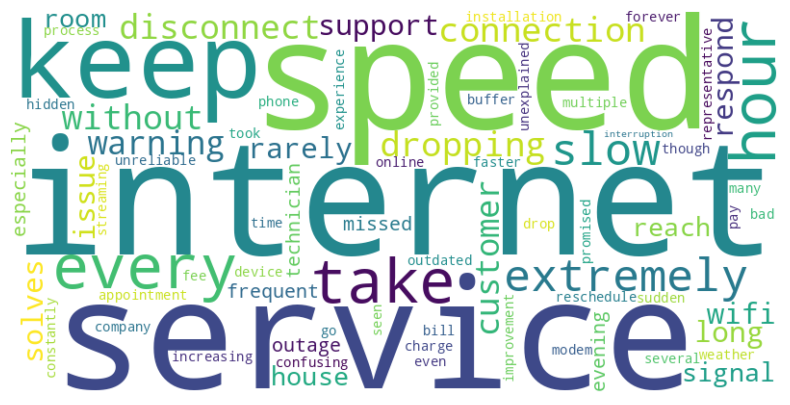

In [51]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
# lemmatized Text
lemmatized_text=[lemmatizer.lemmatize(word) for word in tokens]

# Join tokens to recreate the text as a single string
cleaned_text = ' '.join(lemmatized_text)

# Create a word cloud (note the background color)
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(cleaned_text)

# Display the word cloud using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide the axes
plt.show()

* In the word cloud, the size of each word is proportional to its frequency in the text, with the most common words appearing in the largest font.
* If you have a very voluminous text, Wordcloud can be used as a visual summary of the themes in the content.
* During data pre-processing this information can be used to create classifications for types of complaints.
* Useful communication tool during presentations.

***
# Sentiment Analysis

This is a type of Natural Language Processing focused on identifying and categorizing opinions expressed in a piece of text. For example, we can determine the ratio of positive to negative sentiment in a given text.

Sentiment analysis has several applications
* Monitor customer reviews, social media conversations to understand customer satisfaction
* Sentiment analysis of new articles can be used for market trends
* Automated sentiment analysis can help in prioritizing customer service and support requests based on sentiment expressed

**The NLTK VADER Module**

Valence Aware Dictionary and sEntiment Reasoner

* It is a built-in pretrainded sentiment analyzer from the NLTK package
* Best suited for short text (such as a sentence)
* Does not need pre-processing of text
* Every text is given four normalised scores:
  1. **neu** - how neutral the sentiment is
  2. **neg**- how negative the sentiment is
  3. **pos** - how positive the statement is
  4. **compound** - the overall sentiment of the statement
  5. The **neu**, **neg**, **pos** scores add to 1
  6. The compound score is between -1 and 1
* The compound score can be used as a single unidimensional measure of sentiment for a sentence.
  1. Positive sentiment : **compound** score >= 0.5
  2. Neutral sentiment  : **compound** score netween -0.5 and 0.5
  3. Negative sentiment : **compound** score <= -0.5

A useful resource to understand the scoring
https://vadersentiment.readthedocs.io/en/latest/pages/about_the_scoring.html

In [68]:

import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon
nltk.download('vader_lexicon')

# 1. Create the sample data
data = {
    'review_id': [1, 2, 3, 4, 5, 6],
    'text': [
        # Compliments
        "The new dashboard is incredibly intuitive and visually appealing! I love it.",
        "Excellent customer service. The support team resolved my issue in minutes.",
        "A brilliant update, the performance has improved significantly.",
        # Criticisms
        "Terrible experience. The application crashes every time I try to export a report.",
        "I am very disappointed with the quality of this update; it feels rushed and buggy.",
        "Completely unacceptable wait times and completely unhelpful staff."
    ],
    'expected_type': ['compliment', 'compliment', 'compliment', 'criticism', 'criticism', 'criticism']
}

# 2. Convert to DataFrame
df = pd.DataFrame(data)

# 3. Initialize VADER and compute sentiment
analyzer = SentimentIntensityAnalyzer()


# Add polarity scores to the quotes dataframe
df['scores']= df['text'].apply(analyzer.polarity_scores)

df

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,review_id,text,expected_type,scores
0,1,The new dashboard is incredibly intuitive and ...,compliment,"{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compou..."
1,2,Excellent customer service. The support team r...,compliment,"{'neg': 0.0, 'neu': 0.497, 'pos': 0.503, 'comp..."
2,3,"A brilliant update, the performance has improv...",compliment,"{'neg': 0.0, 'neu': 0.42, 'pos': 0.58, 'compou..."
3,4,Terrible experience. The application crashes e...,criticism,"{'neg': 0.237, 'neu': 0.763, 'pos': 0.0, 'comp..."
4,5,I am very disappointed with the quality of thi...,criticism,"{'neg': 0.207, 'neu': 0.793, 'pos': 0.0, 'comp..."
5,6,Completely unacceptable wait times and complet...,criticism,"{'neg': 0.32, 'neu': 0.68, 'pos': 0.0, 'compou..."


***
# Normalization & Standardization with Scikit-learn

**Standardization** and **Normalization** are two common feature scaling techniques used to bring numerical data onto a similar scale, which is often a crucial step for many machine learning algorithms.

* **Normalization (or Min-Max Scaling)** rescales data to a fixed range, usually **0 to 1**.
* **Standardization (or Z-score Normalization)** rescales data to have a **mean of 0** and a **standard deviation of 1**.



***
### Setup: Sample Data

First, let's create a simple DataFrame. The 'Age' and 'Salary' columns have very different scales, making them perfect candidates for scaling.

In [ ]:
import pandas as pd
import numpy as np

# Create a sample DataFrame
data = {'Age': [25, 30, 35, 40, 45],
        'Salary': [50000, 60000, 75000, 90000, 110000]}
df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)



Scikit-learn's `preprocessing` module provides a much more robust and convenient way to scale data, especially when preparing data for machine learning models.

### Normalization with `MinMaxScaler`

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy
df_sklearn_norm = df.copy()

# 1. Initialize the scaler
scaler = MinMaxScaler()

# 2. Fit and transform the data
df_sklearn_norm[['Age', 'Salary']] = scaler.fit_transform(df_sklearn_norm[['Age', 'Salary']])

print("DataFrame after Scikit-learn Normalization:")
print(df_sklearn_norm)

### Standardization with `StandardScaler`

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a copy
df_sklearn_std = df.copy()

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit and transform the data
df_sklearn_std[['Age', 'Salary']] = scaler.fit_transform(df_sklearn_std[['Age', 'Salary']])

print("\nDataFrame after Scikit-learn Standardization:")
print(df_sklearn_std)

***
### When to Use Which?

* **Use Normalization (Min-Max Scaling)** when you know the distribution of your data does not follow a Gaussian (bell curve) distribution or for algorithms like K-Nearest Neighbors (KNN) that rely on distance measurements.
* **Use Standardization (Z-score)** when your data follows a Gaussian distribution or for algorithms like Linear Regression and Logistic Regression. It's generally considered a safer default choice as it's not as affected by outliers.

# Example of using LLMs for Data Wrangling

In [ ]:
# Here is a sample dataframe
product_review_data = {
    'review_id': ['REV-1042', 'REV-1043', 'REV-1044'],
    'date_submitted': ['2023-10-25', '2023-10-26', '2023-10-26'],
    'user_id': ['U-8472', 'U-1928', 'U-5531'],
    'source': ['Mobile App', 'Web Browser', 'Mobile App'],
    'verified_purchase': [True, True, False],
    'review_text': ["I bought the Dyson V15 yesterday. It's amazing, 10/10!",
    "My iPhone 12 screen cracked immediately. I hate it. I want my money back.",
    "The Nike Air Max shoes are okay, a bit tight but they look nice."]
}

# Create the Pandas DataFrame
df = pd.DataFrame(product_review_data)
df

,review_id,date_submitted,user_id,source,verified_purchase,review_text
0,REV-1042,2023-10-25,U-8472,Mobile App,True,I bought the Dyson V15 yesterday. It's amazing...
1,REV-1043,2023-10-26,U-1928,Web Browser,True,My iPhone 12 screen cracked immediately. I hat...
2,REV-1044,2023-10-26,U-5531,Mobile App,False,"The Nike Air Max shoes are okay, a bit tight b..."


In [ ]:
import pandas as pd
from pydantic import BaseModel, Field
import instructor
from openai import OpenAI

"""
STEP 1: Connecting to the AI model
Ollama follows the OpenAI standard. So we will use the openai library.
'instructor' sits on top of this connection to enable data extraction.
"""
client = instructor.from_openai(
    OpenAI(
        # We redirect the client to look at your own computer instead of the internet
        base_url="http://localhost:11434/v1",
        # The library requires a key, but because we are local, Ollama ignores it
        api_key="ollama",
    ),
    # JSON mode forces the AI to output computer-readable text, not chatty paragraphs
    mode=instructor.Mode.JSON
)

"""
STEP 2: Defining the Schema & Prompt Engineering
We don't need to write a long, complex text prompt.
Instead, we use Pydantic's `Field` to write our instructions directly into the columns.
'Instructor' will read these descriptions and pass them to the AI so it knows
EXACTLY how to analyze and format the data.
"""
class ReviewData(BaseModel):
    product_name: str = Field(
        description="The name of the physical product being reviewed."
    )
    sentiment_score: int = Field(
        description="A score from 1 to 10 based on the user's tone. 10 is extremely positive, 1 is extremely negative."
    )
    review_tone: str = Field(
        description="Tone of the review. Positive, Negative, or Neutral"
    )
"""
STEP 3: Setting up the Extraction Loop
We process the data one piece of text at a time. We send the text AND our blueprint
to the AI, and it sends back the structured data.
"""

# We create an empty list to hold the clean data as it comes back from the AI
extracted_rows = []
print("Extracting data with Gemma4:e2b ...\n")

for text in df["review_text"]:
    extracted_info = client.chat.completions.create(
        # Specify the exact local model you downloaded via Ollama
        model="gemma4:e2b",
        messages=[
            # The 'system' role gives the AI its overarching job description
            {"role": "system", "content": "You are a precise data extraction assistant."},
            # The 'user' role is the specific data we want it to process right now
            {"role": "user", "content": text}
        ],
        # MAGIC ALERT: This tells the AI it MUST use the blueprint we defined in Step 2!
        response_model=ReviewData,

        # --- REPRODUCIBILITY LOCKDOWN ---
        # We want the AI to act like a calculator, not an artist.
        # Temperature 0 removes creativity, and Seed 42 gives it a fixed mathematical starting point.
        temperature=0.0,
        top_p = 0.1,
        seed=42
    )

    # 'extracted_info' is currently a special Pydantic object.
    # .model_dump() translates it back into a standard Python dictionary so Pandas can read it.
    extracted_rows.append(extracted_info.model_dump())

"""
STEP 4: Integration with Data Analytics (Pandas)
Because we forced the AI to give us a clean list of dictionaries,
Pandas can instantly convert it into a DataFrame without any extra cleaning.
"""
df = pd.DataFrame(extracted_rows)

print("--- The Cleaned Tabular Data ---")
print(df)

Extracting data with Gemma4:e2b ...

